# Deep LDA Results
Compare DNLLLoss vs LogisticLoss across 5 runs.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


In [2]:
results_path = Path('cifar100_lda_runs.json')
with results_path.open() as f:
    results = json.load(f)

results['config']


{'dataset': 'CIFAR-100',
 'epochs': 100,
 'runs': 5,
 'batch_size': 256,
 'test_batch_size': 1024,
 'num_classes': 100,
 'embedding_dim': 9,
 'covariance_type': 'spherical',
 'optimizer': 'Adam',
 'lr': 0.001,
 'lambda_reg': 0.01,
 'seed_base': 1234,
 'deterministic': False,
 'device': 'cuda',
 'timestamp': '2026-01-08T19:15:47'}

In [3]:
def stack_metric(loss_runs, key):
    return np.array([run[key] for run in loss_runs], dtype=np.float32)

def summarize_metric(loss_runs, key):
    values = stack_metric(loss_runs, key)
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    return mean, std

def plot_metric(ax, loss_runs, key, label, color):
    mean, std = summarize_metric(loss_runs, key)
    epochs = np.arange(1, len(mean) + 1)
    ax.plot(epochs, mean, label=label, color=color, linewidth=2)
    ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.2)
    return mean, std


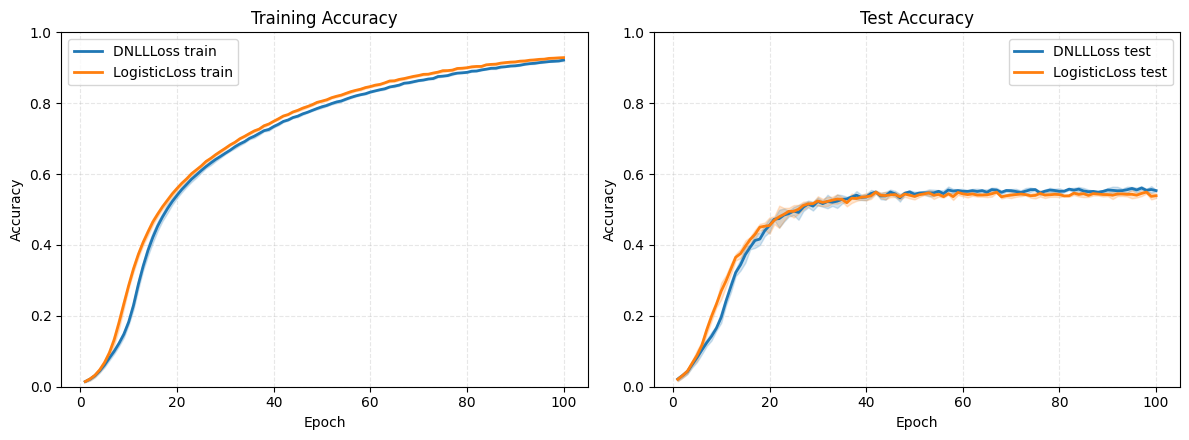

In [4]:
losses = results['losses']
colors = {
    'DNLLLoss': '#1f77b4',
    'LogisticLoss': '#ff7f0e',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for loss_name, loss_runs in losses.items():
    plot_metric(axes[0], loss_runs, 'train_acc', f'{loss_name} train', colors[loss_name])
    plot_metric(axes[1], loss_runs, 'test_acc', f'{loss_name} test', colors[loss_name])

axes[0].set_title('Training Accuracy')
axes[1].set_title('Test Accuracy')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_129856/400922029.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])


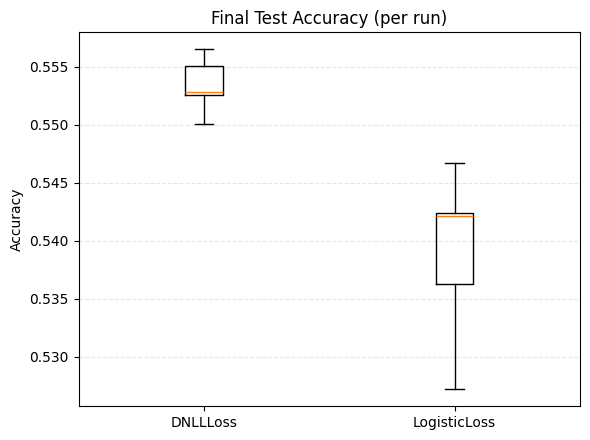

In [5]:
def final_accuracy(loss_runs, key):
    values = stack_metric(loss_runs, key)
    return values[:, -1]

dnll_final = final_accuracy(losses['DNLLLoss'], 'test_acc')
log_final = final_accuracy(losses['LogisticLoss'], 'test_acc')

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
ax.set_title('Final Test Accuracy (per run)')
ax.set_ylabel('Accuracy')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
